# Notebook 04 — Baseline Error Analysis

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Goal**: Understand where and why the baseline model fails — motivating the transformer.

---

## What We're Doing

1. Load the best baseline model (Logistic Regression + TF-IDF)
2. Get all misclassified tweets
3. Analyze error patterns by class
4. Find the most confused class pairs
5. Read actual misclassified Amharic tweets and explain why the model failed
6. Write findings that motivate the transformer

---

In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, accuracy_score
)

pd.set_option('display.max_colwidth', 300)
pd.set_option('display.max_rows', 50)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Model and Data

In [2]:
# ── Load baseline model and vectorizer ────────────────────────
model  = joblib.load('../models/baseline_model.joblib')
tfidf  = joblib.load('../models/tfidf_vectorizer.joblib')

print(f'Model: {type(model).__name__}')
print(f'Vectorizer vocabulary size: {len(tfidf.vocabulary_):,}')

Model: LogisticRegression
Vectorizer vocabulary size: 13,791


In [3]:
# ── Load test data ─────────────────────────────────────────────
test_df = pd.read_parquet('../data/processed/test_clean.parquet')
print(f'Test set: {test_df.shape}')
print(f'Columns: {test_df.columns.tolist()}')
print(f'\nClass distribution:')
print(test_df['sentiment'].value_counts())

Test set: (1999, 4)
Columns: ['tweet', 'clean_tweet', 'label', 'sentiment']

Class distribution:
sentiment
negative    1337
positive     438
neutral      224
Name: count, dtype: int64


In [4]:
# ── Generate predictions ───────────────────────────────────────
X_test = tfidf.transform(test_df['clean_tweet'])
y_true = test_df['sentiment']
y_pred = model.predict(X_test)

print(f'Macro F1: {f1_score(y_true, y_pred, average="macro"):.4f}')
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(f'\nTotal misclassified: {(y_true != y_pred).sum():,} / {len(y_true):,} ({(y_true != y_pred).mean():.1%})')

Macro F1: 0.4640
Accuracy: 0.4997

Total misclassified: 1,000 / 1,999 (50.0%)


## 2. Per-Class Performance

In [5]:
# ── Detailed classification report ────────────────────────────
print('Classification Report:')
print(classification_report(y_true, y_pred, 
      target_names=['negative', 'neutral', 'positive']))

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.48      0.61      1337
     neutral       0.16      0.59      0.26       224
    positive       0.54      0.52      0.53       438

    accuracy                           0.50      1999
   macro avg       0.51      0.53      0.46      1999
weighted avg       0.70      0.50      0.55      1999



In [6]:
# ── Error rate per class ───────────────────────────────────────
test_df = test_df.copy()
test_df['predicted'] = y_pred
test_df['correct'] = (test_df['sentiment'] == test_df['predicted'])

print('Error rate per class:')
for sentiment in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['sentiment'] == sentiment]
    error_rate = (~subset['correct']).mean()
    n_errors = (~subset['correct']).sum()
    print(f'  {sentiment:10s}: {error_rate:.1%} wrong ({n_errors}/{len(subset)})')

Error rate per class:
  negative  : 52.1% wrong (697/1337)
  neutral   : 40.6% wrong (91/224)
  positive  : 48.4% wrong (212/438)


## 3. Confusion Matrix — Where Does the Model Get Confused?

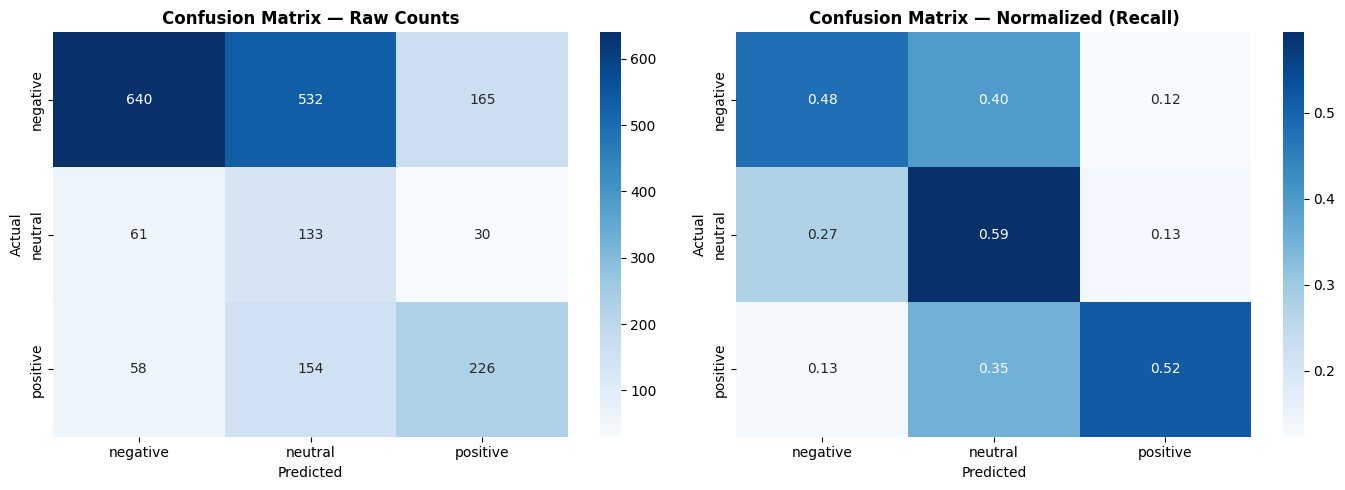

Saved: 04_error_confusion_matrix.png


In [7]:
# ── Confusion matrix ───────────────────────────────────────────
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')

# Normalized by row (recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix — Normalized (Recall)', fontweight='bold')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/04_error_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_error_confusion_matrix.png')

## 4. Most Confused Class Pairs

In [8]:
# ── Which pairs does the model confuse most? ───────────────────
errors_df = test_df[~test_df['correct']].copy()

print('Most common confusion pairs (actual → predicted):')
confusion_pairs = errors_df.groupby(['sentiment', 'predicted']).size()\
    .reset_index(name='count')\
    .sort_values('count', ascending=False)
print(confusion_pairs.to_string(index=False))

Most common confusion pairs (actual → predicted):
sentiment predicted  count
 negative   neutral    532
 negative  positive    165
 positive   neutral    154
  neutral  negative     61
 positive  negative     58
  neutral  positive     30


## 5. Sample Misclassified Tweets

This is the most important section — reading the actual Amharic tweets that the model got wrong and understanding WHY.

In [9]:
# ── Sample errors for each confusion pair ─────────────────────
print('Sample misclassified tweets:\n')

for _, row in confusion_pairs.head(4).iterrows():
    actual = row['sentiment']
    predicted = row['predicted']
    count = row['count']
    
    print(f'=== ACTUAL: {actual.upper()} → PREDICTED: {predicted.upper()} ({count} cases) ===')
    
    samples = errors_df[
        (errors_df['sentiment'] == actual) & 
        (errors_df['predicted'] == predicted)
    ][['tweet', 'clean_tweet']].head(3)
    
    for i, (_, s) in enumerate(samples.iterrows(), 1):
        print(f'  {i}. Original: {s["tweet"]}')
        print(f'     Cleaned:  {s["clean_tweet"]}')
        print()
    print()

Sample misclassified tweets:

=== ACTUAL: NEGATIVE → PREDICTED: NEUTRAL (532 cases) ===
  1. Original: 'ከጎንደር ወደ ገንዳ ውሃ በአባዱላ ሲያቀኑ የነበሩ ተጓዦች ተላላኪው የቅማንት ኮሚቴ ባደራጀው የሽፍታ ቡድን ግድያ እና እገታ ተፈፀመባቸው። አማራ ሚዲያ ማዕከል መስከረም 18 ቀን 2'
     Cleaned:  ከጎንደር ወደ ገንዳ ውሃ በአባዱላ ሲያቀኑ የነበሩ ተጓዦች ተላላኪው የቅማንት ኮሚቴ ባደራጀው የሽፍታ ቡድን ግድያ እና እገታ ተፈጸመባቸው። አማራ ሚዲያ ማእከል መስከረም 18 ቀን 2

  2. Original: 'ጌታቸው ረዳ አብኖችን(መልካሙ ሹምየ) የለመነበት መልዕክት ወጥቷል። ልመናው ከመጨፍጨፍ ስላላዳነው ዛሬ ስለ አብኖች በማጣጣል ጽፏል። የትግራይ ህዝብ ሆይ ጠላትህ አማራ ሳይሆን መ'
     Cleaned:  ጌታቸው ረዳ አብኖችን መልካሙ ሹምየ የለመነበት መልእክት ወጥቷል። ልመናው ከመጨፍጨፍ ስላላዳነው ዛሬ ስለ አብኖች በማጣጣል ጽፏል። የትግራይ ህዝብ ሆይ ጠላትህ አማራ ሳይሆን መ

  3. Original: '@user የክተት ጥሪ ውጠት ማምጣት እንዳልቻለ እና አውንም ውጠት ልያመጣ እንደማይችል አንዱ @user ወጠጤ @user ተናገረ።'
     Cleaned:  የክተት ጥሪ ውጠት ማምጣት እንዳልቻለ እና አውንም ውጠት ልያመጣ እንደማይችል አንዱ ወጠጤ ተናገረ።


=== ACTUAL: NEGATIVE → PREDICTED: POSITIVE (165 cases) ===
  1. Original: '@user መኖር እንዳንተ ከሆነ ለሞቱት ጓዶችህ ሊዘፈንላቸው ይገባል መለቀስ ያለበት ለአንተ ነው'
     Cleaned:  መኖር እንዳንተ ከሆነ ለሞቱት ጓዶችህ ሊዘፈንላቸው ይገባል መለቀስ ያለበት ለአንተ ነው

  2. 

## 6. TF-IDF Limitation Analysis

In [10]:
# ── Words the model associates with each class ─────────────────
# For Logistic Regression: look at the feature coefficients
feature_names = tfidf.get_feature_names_out()
classes = model.classes_

print('Top 15 words the model associates with each class:\n')
for i, cls in enumerate(classes):
    coefs = model.coef_[i]
    top_idx = np.argsort(coefs)[-15:][::-1]
    top_words = [(feature_names[j], round(coefs[j], 3)) for j in top_idx]
    print(f'=== {cls.upper()} ===')
    for word, coef in top_words:
        print(f'  {word}: {coef}')
    print()

Top 15 words the model associates with each class:

=== NEGATIVE ===
  የአብይ: 1.838
  ብሎ: 1.534
  እብድ: 1.48
  ዘረኛ: 1.473
  ራስ: 1.354
  ቆሻሻ: 1.342
  የላቸውም: 1.321
  ደነዝ: 1.321
  ምን: 1.273
  ይሆን: 1.264
  ብቻ: 1.224
  ወረኛ: 1.205
  አስመሳይ: 1.158
  ምቀኛ: 1.137
  በኢትዮጵያ: 1.119

=== NEUTRAL ===
  ወቅት: 1.063
  ሆነ: 1.035
  ወይስ: 0.94
  2012: 0.931
  አሉ: 0.929
  መስሎኝ: 0.906
  ፖሊሲ: 0.904
  መረጃ: 0.898
  እስኪ: 0.889
  አሜሪካ: 0.853
  እና: 0.851
  ለማለት: 0.845
  ሙሉ: 0.808
  ምን: 0.802
  ወዴት: 0.8

=== POSITIVE ===
  መልካም: 3.328
  ደስ: 2.194
  ጥሩ: 2.111
  እግዚአብሄር: 2.096
  እናመሰግናለን: 2.046
  ድል: 1.975
  አሜን: 1.919
  ጀግና: 1.862
  አመሰግናለሁ: 1.781
  እውነት ነው: 1.693
  ምርጥ: 1.67
  ድንቅ: 1.529
  ይሁን: 1.464
  ውብ: 1.418
  ከጎንህ: 1.328



Error rate by tweet length:
length_bucket  error_rate  count
          1-5    0.477528    178
         6-10    0.494781    479
        11-15    0.482051    390
        16-20    0.510022    449
          20+    0.518887    503


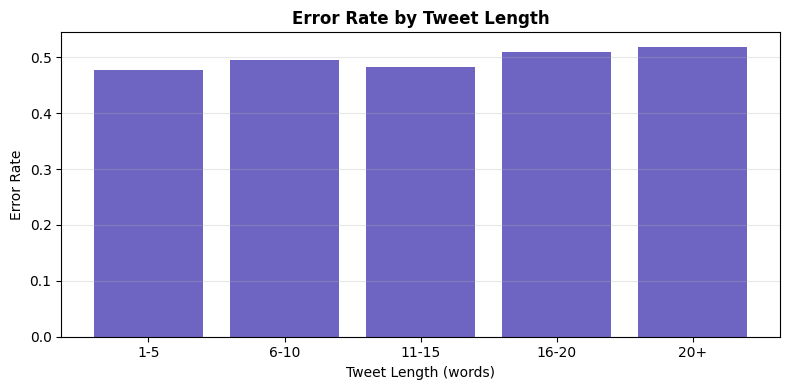

In [11]:
# ── Tweet length vs error rate ─────────────────────────────────
test_df['word_count'] = test_df['clean_tweet'].str.split().str.len()
test_df['length_bucket'] = pd.cut(test_df['word_count'], 
                                   bins=[0, 5, 10, 15, 20, 100],
                                   labels=['1-5', '6-10', '11-15', '16-20', '20+'])

error_by_length = test_df.groupby('length_bucket')['correct'].agg(
    error_rate=lambda x: (~x).mean(),
    count='count'
).reset_index()

print('Error rate by tweet length:')

print(error_by_length.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(error_by_length['length_bucket'].astype(str), 
       error_by_length['error_rate'],
       color='#534AB7', alpha=0.85)
ax.set_xlabel('Tweet Length (words)')
ax.set_ylabel('Error Rate')
ax.set_title('Error Rate by Tweet Length', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_error_by_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Findings & Motivation for Transformer

Fill this in after reading the misclassified tweets:

| Finding | Detail |
|---|---|
| Hardest class | Fill in |
| Most confused pair | Fill in |
| Error rate on neutral | Fill in |
| Error rate on negative | Fill in |
| Error rate on positive | Fill in |

**Why TF-IDF fails on Amharic (your observations)**:

1. **Context blindness** — TF-IDF treats each word independently. Amharic sentiment often depends on the combination of words, not individual words. Example: a word that is positive alone can be sarcastic in context.

2. **Morphological complexity** — Amharic is a highly morphological language. One root word has dozens of forms (prefixes, suffixes, gender markers). TF-IDF treats each form as a completely different word, fragmenting the signal.

3. **Mixed script confusion** — Tweets mixing Amharic and Latin (code-switching) split the signal across two vocabularies. TF-IDF has no way to connect them semantically.

4. **Neutral class confusion** — Neutral tweets often contain both positive and negative words, making bag-of-words models flip to whichever word type dominates — missing the overall neutral tone.

**Why the transformer will do better**:
- Afro-XLM-R was pre-trained on 17 African languages including Amharic
- It understands word ORDER and CONTEXT — not just word frequency
- It handles morphological variants through subword tokenization (BPE)
- It can connect Amharic and Latin words semantically through shared embeddings

**Next steps (Day 6 — Tokenization)**:
- Load Afro-XLM-R tokenizer
- Tokenize the Amharic dataset
- Build PyTorch Dataset class
- Verify data loaders work correctly